In [7]:
!pip install trimesh
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from sphere_volume_DDG_functions import *


Python(28145) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


ImportError: cannot import name 'plot_surface_mesh' from 'sphere_volume_DDG_functions' (/Volumes/Songyi Deng/songyidengx/Downloads/ddgclib/sphere_volume_DDG_functions.py)

In [4]:
# Main experiment parameters
radius = 1.0
subdivisions_range = range(0, 6)
tet_counts = []
relerr_corr = []
relerr_flat = []
# Show initial mesh before loop
surface_pts, surface_faces, all_points, tets = GeoMesh(subdivisions=0, radius=radius)
plot_surface_mesh(surface_pts, surface_faces, title='Initial Mesh (subdivisions=0)')

for subdivisions in subdivisions_range:
    surface_pts, surface_faces, all_points, tets = GeoMesh(subdivisions=subdivisions, radius=radius)
    vertex_curvature = DDG_curvature(surface_pts, surface_faces)
    total_corr = 0.0
    total_flat = 0.0
    for tet in tets:
        iA, iB, iC, iD = tet
        a, b, c, d = all_points[iA], all_points[iB], all_points[iC], all_points[iD]
        kA, kB, kC = vertex_curvature[iA], vertex_curvature[iB], vertex_curvature[iC]
        V_corr, V_flat = curvature_corrected_volume(a, b, c, d, kA, kB, kC)
        total_corr += V_corr
        total_flat += V_flat
    theoretical = (4/3)*np.pi*radius**3
    tet_counts.append(len(tets))
    relerr_corr.append(100 * abs(total_corr - theoretical) / theoretical)
    relerr_flat.append(100 * abs(total_flat - theoretical) / theoretical)
    # Print requested information
    print(f"subdivisions = {subdivisions}")
    print("Average curvature (should be close to 1.0):", vertex_curvature.mean())
    print("Std curvature:", vertex_curvature.std())
    print(f"Total computed volume with curvature correction: {total_corr:.6f}")
    print(f"Sum of all flat tet volumes (no correction, surface-based tets): {total_flat:.6f}")
    print(f"Theoretical sphere volume: {theoretical:.6f}")
    print(f"Number of tets: {len(tets)}")
    print(f"Error in volume: {abs(total_corr - theoretical) / theoretical:.6f} (should be small)")
    print("-"*50)


subdivisions = 0
Average curvature (should be close to 1.0): 0.9999999999999997
Std curvature: 0.0
Total computed volume with curvature correction: 3.191514
Sum of all flat tet volumes (no correction, surface-based tets): 2.536151
Theoretical sphere volume: 4.188790
Number of tets: 20
Error in volume: 0.238082 (should be small)
--------------------------------------------------
subdivisions = 1
Average curvature (should be close to 1.0): 1.021532182692301
Std curvature: 0.10082593941439016
Total computed volume with curvature correction: 3.898223
Sum of all flat tet volumes (no correction, surface-based tets): 3.658712
Theoretical sphere volume: 4.188790
Number of tets: 80
Error in volume: 0.069368 (should be small)
--------------------------------------------------
subdivisions = 2
Average curvature (should be close to 1.0): 1.2515339300901562
Std curvature: 0.22863396878595602
Total computed volume with curvature correction: 4.125780
Sum of all flat tet volumes (no correction, surfac

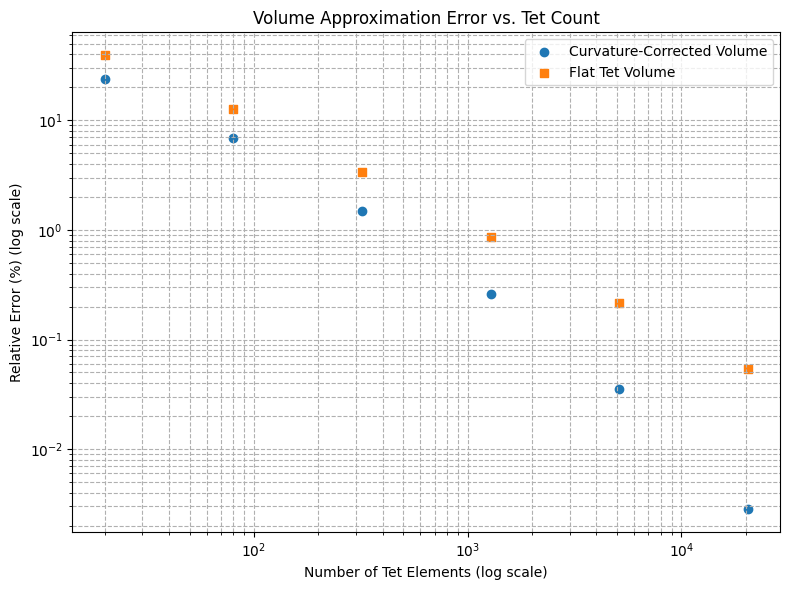

In [5]:
# Plotting
plt.figure(figsize=(8,6))
plt.scatter(tet_counts, relerr_corr, label='Curvature-Corrected Volume', color='C0', marker='o')
plt.scatter(tet_counts, relerr_flat, label='Flat Tet Volume', color='C1', marker='s')
#plt.axhline(0, color='k', linestyle='--', label='Theoretical Sphere Volume (0% error)')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Tet Elements (log scale)')
plt.ylabel('Relative Error (%) (log scale)')
plt.title('Volume Approximation Error vs. Tet Count')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()